# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
  import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
  PKG = %pwd
  PKG = pathlib.Path(PKG)
  root_parent_level = 2
  root = PKG
  full_pkg = f"{root.name}"
  for _ in range(root_parent_level):
    root = root.parent
    full_pkg = f"{root.name}.{full_pkg}"
    MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
    MODULE_NAME = f"{root.name}"
    spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
  __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Figures Save Path

In [3]:
save_prefix = r"../../results/RLModel/"
import pathlib
try:
    pathlib.Path(save_prefix).mkdir(exist_ok=True)
except:
    print("Failed to create save dir...")

# Load model fitting

In [73]:
import pickle
from pathlib import Path

def loadAll(key=None):
    evolve_res_dict_dict = {}
    for fp in Path("../../data/RLModel").iterdir():
        if not fp.is_file() or not fp.name.endswith(".pkl"):
            continue
        if key is not None and key not in fp.name:
            continue
        with fp.open("rb") as f:
            _evolve_loaded = pickle.load(f)
            evolve_res_dict_dict[fp.name] = _evolve_loaded
            print(f"Loaded: {fp.name}")
            
        evolve_res_dict_dict[fp.name] = _evolve_loaded
            
    return evolve_res_dict_dict

# Load Q-Value + Reward Rate DDM model results
KEY = "NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl"
evolve_res_dict_dict = loadAll(key=KEY)

Loaded: NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl


# Fit data and resample if required

In [67]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from .model.logic import makeOneRun


def runDataFit(df, *, include_Q, include_RewardRate, 
               biasFn, biasFn_df_cols, biasFn_kwargs,
               driftFn, driftFn_df_cols, driftFn_kwargs,
               noiseFn, noiseFn_df_cols, noiseFn_kwargs,
               ALPHA, BETA, NON_DECISION_TIME,
               DRIFT_COEF, NOISE_SIGMA, BOUND, dt, t_dur):
    ret = makeOneRun(df, include_Q=include_Q, include_RewardRate=include_RewardRate,
                     biasFn=biasFn,   biasFn_df_cols=biasFn_df_cols,   biasFn_kwargs=biasFn_kwargs,
                     driftFn=driftFn, driftFn_df_cols=driftFn_df_cols, driftFn_kwargs=driftFn_kwargs,
                     noiseFn=noiseFn, noiseFn_df_cols=noiseFn_df_cols, noiseFn_kwargs=noiseFn_kwargs,
                     ALPHA=ALPHA, BETA=BETA, NON_DECISION_TIME=NON_DECISION_TIME,
                     DRIFT_COEF=DRIFT_COEF, NOISE_SIGMA=NOISE_SIGMA,
                     BOUND=BOUND, dt=dt, t_dur=t_dur, return_df=True)
    return ret

def _resampleSess(concat_subj_df, resample_count, random_dv=False):
    print_once = True # Change to false to debug and print only once
    rndm_gen = np.random.Generator(np.random.PCG64(0))  # For reproducibility
    def resampleFn(sess_df):
        nonlocal print_once
        sess_df = sess_df.copy()
        trial_number = sess_df["TrialNumber"].values.copy()
        valid_idx = sess_df["valid"]
        sess_df.loc[valid_idx, :] = sess_df.loc[valid_idx, :].sample(frac=1, replace=True,
                                                                     random_state=rndm_gen).values
        sess_df["TrialNumber"] = trial_number
        if not print_once:
            print_once = True
            display(sess_df[sess_df["valid"]].TrialNumber)
        assert sess_df[sess_df["valid"]].TrialNumber.is_monotonic_increasing, (
            display(sess_df[sess_df["valid"]].TrialNumber) or
            "TrialNumber is not monotonic increasing after resampling")
        return sess_df
    
    uniq_sess = concat_subj_df[["Name", "Date", "SessionNum"]
                               ].drop_duplicates().reset_index(drop=True)
    resampled_sess_li = []
    for count in tqdm(range(len(uniq_sess)*resample_count),
                      desc="Resampling sessions"):
        # Pick a random session and resample it
        sess_idx = rndm_gen.choice(uniq_sess.index)
        sess_row = uniq_sess.iloc[sess_idx]
        sess_df = concat_subj_df[(concat_subj_df["Name"] == sess_row["Name"]) &
                                 (concat_subj_df["Date"] == sess_row["Date"]) &
                                 (concat_subj_df["SessionNum"] == sess_row["SessionNum"])]
        if not random_dv:
            sess_df = resampleFn(sess_df)
        else:
            sess_df = sess_df.copy()
        sess_df["SessionNum"] = f"Random_{count}"
        sess_df["SessId"] = f"{sess_row['Name']}_{sess_row['Date']}_Random_{count}"
        resampled_sess_li.append(sess_df)
    concat_rndm_df = pd.concat(resampled_sess_li)
    if random_dv:
        concat_rndm_df["DV"] = rndm_gen.uniform(-1, 1, size=len(concat_rndm_df))
        concat_rndm_df["LeftRewarded"] = concat_rndm_df["DV"] > 0
        zero_dv_mask = concat_rndm_df["DV"] == 0
        if zero_dv_mask.any():
            concat_rndm_df.loc[concat_rndm_df, "LeftRewarded"] = \
                        rndm_gen.choice([True, False],  size=zero_dv_mask.sum())
    concat_subj_df = pd.concat([concat_subj_df, concat_rndm_df],
                                ignore_index=True).reset_index(drop=True)
    # display(concat_subj_df)
    return concat_subj_df
    

def combineDFs(evolve_res, key, resample_count=100, random_dv=False):
    # key example: "NoiseGain-RewardRate_biasQ-Val_Normal(0, 1)_3s_dt0.005.pkl"
    key_split = key.replace(".pkl", "").split("_")
    DT = float(key_split[-1].strip("dt"))
    T_DUR = float(key_split[-2].strip("s"))
    example_subj = next(iter(evolve_res.values()))
    # print("Example subject:", example_subj.keys())
    FIXED_PARAMS_NAMES = list(example_subj["fixed_params_names"])
    # print("PARAMS_NAMES:", FIXED_PARAMS_NAMES)
    FIXED_PARAMS_VALS = example_subj["fixed_params_vals"]
    Include_Q = bool(FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("include_Q")])
    Include_RewardRate = bool(FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("include_RewardRate")])
    BiasFn = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("biasFn")]
    DriftFn = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("driftFn")]
    NoiseFn = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("noiseFn")]

    BIAS_KWARGS_KEYS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("biasFn_kwargs")]
    DIFT_KWARGS_KEYS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("driftFn_kwargs")]
    NOISE_KWARGS_KEYS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("noiseFn_kwargs")]
    # print("Bias Fn:", BiasFn, "BiasFn_kwargs:", BIAS_KWARGS_KEYS)
    # print("Drift Fn:", DriftFn, "DriftFn_kwargs:", DIFT_KWARGS_KEYS)
    # print("Noise Fn:", NoiseFn, "NoiseFn_kwargs:", NOISE_KWARGS_KEYS)
    
    DRIFT_FN_COLS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("driftFn_df_cols")]
    NOISE_FN_COLS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("noiseFn_df_cols")]
    BIAS_FN_COLS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("biasFn_df_cols")]

    DF_IDX = FIXED_PARAMS_NAMES.index("df")
    concat_subj_df = []
    for subj, subject_res in evolve_res.items():
        _subj_df = subject_res["fixed_params_vals"][DF_IDX]
        _subj_df = _subj_df.copy()
        _subj_df["Name"] = subj # Fix the subject name
        concat_subj_df.append(_subj_df)
    concat_subj_df = pd.concat(concat_subj_df, ignore_index=True).reset_index(drop=True)
    if resample_count > 0:
         concat_subj_df = _resampleSess(concat_subj_df, resample_count, random_dv=random_dv)
 
    df_li = []
    for subject, subject_res in evolve_res.items():
        print("Processing subject:", subject)
        subj_fixed_parmas_vals = subject_res["fixed_params_vals"]
        subj_params_names = list(subject_res["params_names"]) # Also convert from numpy array to list
        subject_fit_params_vals = subject_res["OptimRes"]["x"]
        
        # print("Params names:", subj_params_names)
        # subj_df = subj_fixed_parmas_vals[DF_IDX]
        subj_df = concat_subj_df[concat_subj_df["Name"] == subject].copy()


        DRIFT_COEF = float(subject_fit_params_vals[subj_params_names.index("DRIFT_COEF")])
        NOISE_SIGMA = float(subject_fit_params_vals[subj_params_names.index("NOISE_SIGMA")])
        BOUND = float(subject_fit_params_vals[subj_params_names.index("BOUND")])
        ALPHA = float(subject_fit_params_vals[subj_params_names.index("ALPHA")])
        BETA = float(subject_fit_params_vals[subj_params_names.index("BETA")])
        NON_DECISION_TIME = float(subject_fit_params_vals[subj_params_names.index("NON_DECISION_TIME")])

        driftFn_kwargs = {k: float(subject_fit_params_vals[subj_params_names.index(k)]) for k in DIFT_KWARGS_KEYS}
        noiseFn_kwargs = {k: float(subject_fit_params_vals[subj_params_names.index(k)]) for k in NOISE_KWARGS_KEYS}
        biasFn_kwargs = {k: float(subject_fit_params_vals[subj_params_names.index(k)]) for k in BIAS_KWARGS_KEYS}
        
        ret = runDataFit(subj_df, include_Q=Include_Q, include_RewardRate=Include_RewardRate,
                         biasFn=BiasFn, biasFn_df_cols=BIAS_FN_COLS, biasFn_kwargs=biasFn_kwargs,
                         driftFn=DriftFn, driftFn_df_cols=DRIFT_FN_COLS, driftFn_kwargs=driftFn_kwargs,
                         noiseFn=NoiseFn, noiseFn_df_cols=NOISE_FN_COLS, noiseFn_kwargs=noiseFn_kwargs,
                         ALPHA=ALPHA, BETA=BETA, NON_DECISION_TIME=NON_DECISION_TIME,
                         DRIFT_COEF=DRIFT_COEF, NOISE_SIGMA=NOISE_SIGMA,
                         BOUND=BOUND, dt=DT, t_dur=T_DUR)
        _, subj_df = ret
        df_li.append(subj_df)
    res_df = pd.concat(df_li, ignore_index=True).reset_index(drop=True)
    res_df = res_df[res_df["valid"]]
    return res_df

df_model_behavior = combineDFs(evolve_res_dict_dict[KEY], KEY,
                               resample_count=10_000, random_dv=True)

Resampling sessions:   0%|          | 0/400000 [00:00<?, ?it/s]

Processing subject: Avgat1
Processing subject: Avgat2
Processing subject: Avgat3
Processing subject: BVGAT1
Processing subject: GP4-24
Processing subject: GP4-80
Processing subject: GP4-81
Processing subject: GP4-85
Processing subject: RDK_WT1
Processing subject: RDK_WT6
Processing subject: Rbp4_M2_1
Processing subject: WF10
Processing subject: WF11
Processing subject: vgat-40
Processing subject: vgat-94
Processing subject: vgat-95
Processing subject: vgat-96
Processing subject: vgat2.5
Processing subject: vgatchr2-sk
Processing subject: widefield_1


## As Surface Plot

In [15]:
%matplotlib inline
# %matplotlib widget # Enable for interactive plots

## Fig. 5f, middle

twod_num_observ: (11, 21, 4)  - Max: 2959436.0


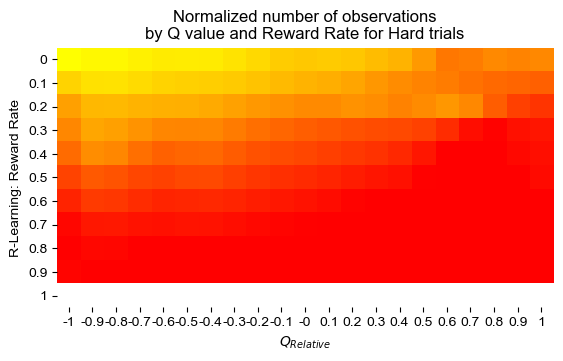

Easy data shape: (11, 21)  - Med data shape: (11, 21)  - Hard data shape: (11, 21)
Current xlim: (-1.1, 1.0999999999999996)
Current ylim: (-0.05, 1.05)
Current zlim: (-0.8218320083412667, 3.202397338849314)
Current viewing angle: -60 30


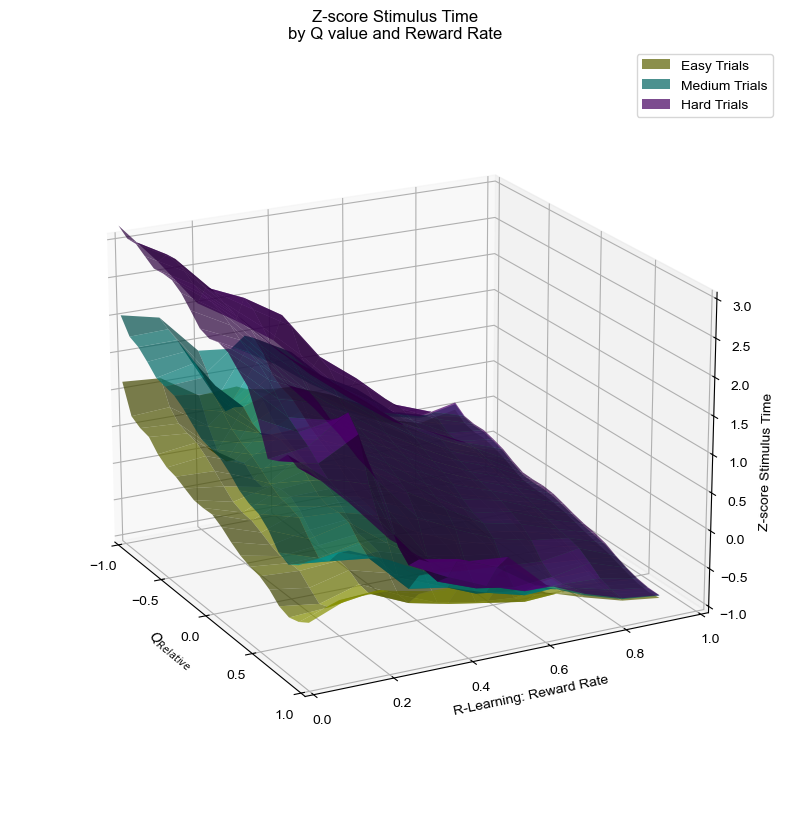

In [69]:
from ..common.clr import Difficulty as DifficultyColor
from ..pipeline.utils import filterNanGaussianConserving
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore


def plotQ_R_Heatmap(df, save_figs=False):
    df = df.copy()
    df = df[df["SimChoiceCorrect"] == True]
    
    BIN_SIZE = 0.1
    NUM_BINS = int(1/BIN_SIZE) + 1
    BINS_RewardRate = np.arange(0, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    Bins_QVal = np.arange(-1, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    # Bins_QVal[0] -= 1e-6  # To include outliers on the left edge
    # print("Number of bins:", NUM_BINS, 
    #       "\n\t- Bins:", BINS_RewardRate,
    #       "\n\t- Long Bins:", Bins_QVal)
    DV_BIN_SIZE = 1/3
    DV_BINS = np.arange(0, 1 + DV_BIN_SIZE, DV_BIN_SIZE)
    # print("Number of DV bins:", DV_BINS.shape[0], " - Bins:", DV_BINS)
    twod_res = np.zeros((BINS_RewardRate.shape[0], Bins_QVal.shape[0], DV_BINS.shape[0]),
                        dtype=np.float64)
    twod_num_observ = np.zeros((BINS_RewardRate.shape[0], Bins_QVal.shape[0], DV_BINS.shape[0]),
                               dtype=np.float64)
    # print("2d array shape:", twod_res.shape)
  
    df["Q_relative"] = df["Q_val"].abs() * (np.sign(df["DV"]) * np.sign(df["Q_val"]))
    dv_0_idx = df["DV"] == 0
    df.loc[dv_0_idx, "Q_relative"] = df.loc[dv_0_idx, "Q_val"]
    
    df["RewardRate_digi"] = np.digitize(df["RewardRate"], bins=BINS_RewardRate, right=True,)
    df["Q_relative_digi"] = np.digitize(df["Q_relative"], bins=Bins_QVal, right=True)
    df["DV_digi"] = np.digitize(df["DV"].abs(), bins=DV_BINS, right=True)
    
    res_df = df.copy()
    res_df["zscore_time"] = np.nan
    for subj, subj_df in df.groupby("Name"):
        zscore_time = zscore(subj_df["SimRT"].values)
        res_df.loc[subj_df.index, "zscore_time"] = zscore_time
   
    def countEntries(grp_df):
        rr_bin_idx = grp_df["RewardRate_digi"].values - 1
        q_bin_idx = grp_df["Q_relative_digi"].values - 1
        dv_idx = grp_df["DV_digi"].values - 1
        twod_res[rr_bin_idx, q_bin_idx, dv_idx] = grp_df["zscore_time"].sum()
        twod_num_observ[rr_bin_idx, q_bin_idx, dv_idx] = len(grp_df)
    res_df.groupby(["RewardRate_digi", "Q_relative_digi", "DV_digi"]).apply(countEntries)
            
    # Plot zero entries heatmap
    # fig, ax = plt.subplots()
    # # ax.imshow(twod_num_observ[:, :, 0] == 0, cmap="autumn")
    # print("Twod num observ shape:", twod_num_observ.shape)
    # print("twod_num_observ[:, 4, 0]")
    # # ax.bar(np.arange(twod_num_observ.shape[1]), np.log(twod_num_observ[3, :, 0]))
    # qval_hard = df[df["DV_digi"] == 1]["Q_relative"]
    # ax.hist(qval_hard, bins=200)#Bins_QVal)
    # plt.show()
    # Normalize by number of subjects
    twod_res = np.divide(twod_res, twod_num_observ, where=twod_num_observ != 0)
    MIN_NUM_OBSERV = 1
    twod_res[twod_num_observ <= MIN_NUM_OBSERV] = np.nan  # Set empty bins to NaN to reduce noise
    #
    fig_hist, ax_imshow = plt.subplots()
    print("twod_num_observ:", twod_num_observ.shape, " - Max:", twod_num_observ.max())
    twod_num_observ[twod_num_observ <= MIN_NUM_OBSERV] = np.nan  # Set empty bins to NaN to reduce noise
 
    twod_res = filterNanGaussianConserving(twod_res, sigma=1.0, axis=1)

    norm_observ = twod_res[:, :, 0].astype(float)/np.nanmax(twod_res[:, :, 0])
    ax_imshow.imshow(norm_observ, cmap="autumn", vmin=0, vmax=1)
    ax_imshow.set_xticks(Bins_QVal/BIN_SIZE - min(Bins_QVal/BIN_SIZE))
    ax_imshow.set_xticklabels([f"{np.round(_bin, 3):.2g}" for _bin in Bins_QVal])
    ax_imshow.set_yticks(BINS_RewardRate/BIN_SIZE)
    ax_imshow.set_yticklabels([f"{_bin:.2g}" for _bin in BINS_RewardRate])
    ax_imshow.set_xlabel("$Q_{Relative}$")
    ax_imshow.set_ylabel("R-Learning: Reward Rate")
    ax_imshow.set_title("Normalized number of observations\nby Q value and "
                        "Reward Rate for Hard trials")
    ax_imshow.spines[["top", "right", "bottom", "left"]].set_visible(False)
    plt.show()
    

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "3d"})
    # twod_res = twod_res.transpose((1, 2, 0))  # Transpose to have Q on x-axis and RewardRate on y-axis
    easy_data = twod_res[:, :, 2]
    med_data = twod_res[:, :, 1]
    hard_data = twod_res[:, :, 0]
    print("Easy data shape:", easy_data.shape, " - Med data shape:", med_data.shape,
            " - Hard data shape:", hard_data.shape)
               
    for (color, data, name) in [(DifficultyColor.Easy, easy_data, "Easy"),
                                (DifficultyColor.Med,  med_data, "Medium"),
                                (DifficultyColor.Hard, hard_data, "Hard")
                                ]:
        # MAke a plot surface where height is zscore time
        X, Y = np.meshgrid(Bins_QVal, BINS_RewardRate)
        surf = ax.plot_surface(X, Y, data, 
                               color=color, alpha=0.7, rstride=1, cstride=1,
                               linewidth=0, antialiased=True,
                               label=f"{name} Trials")
    ax.legend()
    # Set ticks and labels
    # print("Ticks:", LONG_BINS/BIN_SIZE)
    ax.set_xticks(np.arange(-1, 1.25, 0.5))
    ax.set_xlabel("$Q_{Relative}$")
    ax.set_ylabel("R-Learning: Reward Rate")
    ax.set_zlabel("Z-score Stimulus Time")
    ax.set_title("Z-score Stimulus Time\nby Q value and Reward Rate")
    # Print current viewing angle
    # PRint axes limits
    print("Current xlim:", ax.get_xlim())
    print("Current ylim:", ax.get_ylim())
    print("Current zlim:", ax.get_zlim())
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(-1, 3)
    print("Current viewing angle:", ax.azim, ax.elev)
    # Set viewer angle
    ax.view_init(azim=-27.5, elev=20,)
    ax.set_box_aspect(aspect=None, zoom=.9)
    # Set tight layout
    if save_figs:
        fig.savefig(f"{save_prefix}/Q_R_Heatmap.svg", dpi=300,
                    bbox_inches='tight')
    plt.show()


plotQ_R_Heatmap(df_model_behavior, save_figs=True)